# Logistic Regression

In [236]:
log_fit = log_model.fit(x_train_res, y_train_res)

In [237]:
log_model.score(x_train_res, y_train_res)

0.969195457840058

In [238]:
log_model.score(x_test, y_test)

0.9552874378992193

In [239]:
y_predlog = log_model.predict(x_test)

In [240]:
Log_accuracy = np.mean( y_test==y_predlog)
print(f"The Accuracy of Logistic Regression is {Log_accuracy*100}")

The Accuracy of Logistic Regression is 95.52874378992193


In [241]:
log_val = log_model.predict_proba(x_train_res)

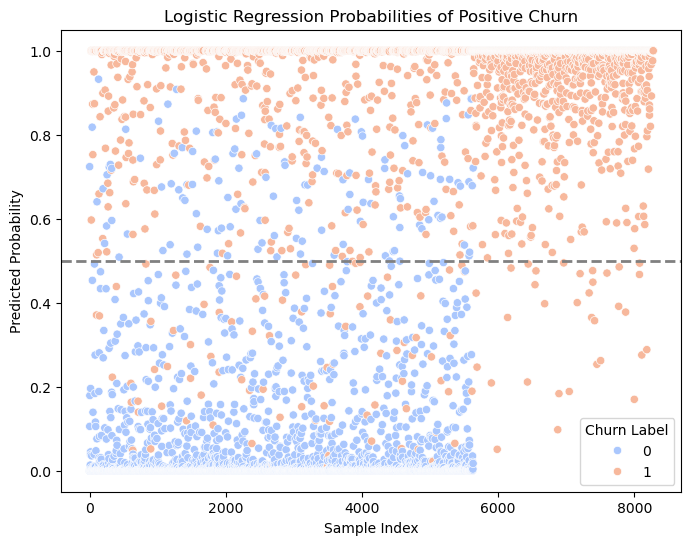

In [242]:
plt.figure(figsize=(8,6))

sb.scatterplot(
    x= range(len(log_val)),
    y= log_val[:,1],
    hue= y_train_res,
    palette="coolwarm")
plt.axhline(y=0.5, color='grey', linestyle='--', linewidth=2)
plt.title("Logistic Regression Probabilities of Positive Churn")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.show()

## Model separates many customers Positive clearly 
## Some customers are borderline cases that is fine 

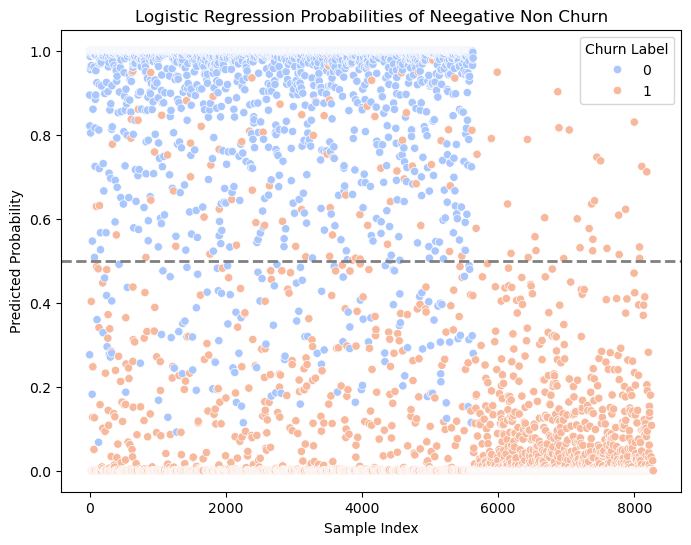

In [243]:
plt.figure(figsize=(8,6))

sb.scatterplot(
    x= range(len(log_val)),
    y= log_val[:,0],
    hue= y_train_res,
    palette="coolwarm")
plt.axhline(y=0.5, color='grey', linestyle='--', linewidth=2)
plt.title("Logistic Regression Probabilities of Neegative Non Churn")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.show()

## Blue points (true non-churn) mostly near 0.8–1
## Orange points mostly near 0–0.2

## Model is confident | Features are informative | Decision boundary is meaningful

In [244]:
from sklearn.metrics import confusion_matrix, classification_report ,roc_curve, precision_recall_curve, auc

# Confusion Matrix of Logistic Regression

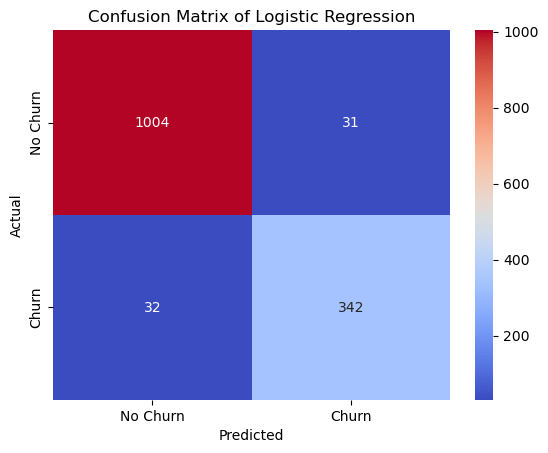

In [245]:
sb.heatmap( confusion_matrix(y_test,y_predlog), 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Logistic Regression")
plt.show()

In [246]:
y_test.value_counts()

Churn Label
0    1035
1     374
Name: count, dtype: int64

## True Positive (Churn Customer) of samples 374 model identifies 347 the number of churn customer identification is better
## True Negative (Non Churn Customers) of samples 1035 model identifies 1001
## False Positive 34 and False Negative are equaly 27

# Classification Report of Logistic Regression

In [247]:
log_cl_rep = pd.DataFrame(classification_report(y_test,y_predlog, output_dict = True))
log_cl_rep

,0,1,accuracy,macro avg,weighted avg
precision,0.969112,0.916890,0.955287,0.943001,0.955250
recall,0.970048,0.914439,0.955287,0.942243,0.955287
f1-score,0.969580,0.915663,0.955287,0.942621,0.955268
support,1035.000000,374.000000,0.955287,1409.000000,1409.000000


## Precison Recall of both Churn and Non Churn (0, 1) are good with  95 percent accuracy
## TheRecall value of churn captured by the model is 92 percent better than precision, because more non churn into churn has increased 
## f1 score with balanced recall precision score is good with 97% (non Churn) and 91% (churn)
## This model predicts Non churn slightly perfect then Churn Customers
## This Precision score insists that sometime can spend non churn customers for retaining

# Grid Search Parameter Tuning

In [248]:
from sklearn.model_selection import GridSearchCV

In [249]:
param_grid = {'C': np.logspace(-3, 3, 15) ,'penalty': ['l2'],'class_weight': [None, 'balanced']}

In [250]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

In [251]:
pipe = Pipeline([
       ('select', SelectKBest(score_func=f_classif)),
       ('model', LogisticRegression(max_iter=1000))])

In [252]:
param_grid = {'select__k': [5, 10, 15, 20],
              'model__C': [0.01, 0.1, 1, 10],
              'model__penalty': ['l2'],
              'model__solver': ['lbfgs']}


In [253]:
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc')

In [254]:
grid.fit(x_train_res, y_train_res)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], 'select__k': [5, 10, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,score_func,<function f_c...002018054C1F0>


In [255]:
pd.DataFrame(grid.best_params_, index= [0])

,model__C,model__penalty,model__solver,select__k
0,10,l2,lbfgs,20


In [256]:
best_pipe = grid.best_estimator_

In [257]:
results = pd.DataFrame(grid.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__solver,param_select__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.030198,0.004380,0.008327,0.001505,0.01,l2,lbfgs,5,"{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 5}",0.985296,0.985495,0.992000,0.993237,0.990180,0.989242,0.003288,16
1,0.062477,0.061344,0.004042,0.002146,0.01,l2,lbfgs,10,"{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 10}",0.990041,0.988936,0.995143,0.995299,0.994070,0.992698,0.002677,12
2,0.028284,0.003957,0.005998,0.005296,0.01,l2,lbfgs,15,"{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 15}",0.990338,0.989428,0.995531,0.995235,0.994026,0.992911,0.002540,11
3,0.032189,0.003490,0.006203,0.004834,0.01,l2,lbfgs,20,"{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 20}",0.990429,0.989745,0.995491,0.995036,0.994135,0.992967,0.002402,10
4,0.029961,0.002327,0.006080,0.004228,0.10,l2,lbfgs,5,"{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 5}",0.986643,0.986458,0.993030,0.994242,0.991159,0.990306,0.003221,15


In [258]:
top_five = results[results["rank_test_score"]<6].sort_values(by ="rank_test_score")

## Top five Ranked parameters

In [259]:

top_five

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__solver,param_select__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
15,0.044842,0.003744,0.006802,0.004117,10.0,l2,lbfgs,20,"{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 20}",0.993299,0.992532,0.997560,0.997060,0.996352,0.995361,0.002047,1
14,0.040489,0.003199,0.003554,0.003182,10.0,l2,lbfgs,15,"{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 15}",0.993048,0.992280,0.997647,0.997202,0.996365,0.995308,0.002212,2
11,0.034231,0.004882,0.008554,0.003272,1.0,l2,lbfgs,20,"{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 20}",0.992993,0.992332,0.997445,0.996926,0.996111,0.995161,0.002095,3
10,0.033075,0.003801,0.006341,0.005019,1.0,l2,lbfgs,15,"{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 15}",0.992695,0.992094,0.997519,0.997038,0.996092,0.995088,0.002254,4
13,0.036348,0.005084,0.006905,0.002588,10.0,l2,lbfgs,10,"{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'select__k': 10}",0.992501,0.991299,0.996803,0.997135,0.995723,0.994692,0.002358,5


In [260]:
top_five["param_select__k"]

15    20
14    15
11    20
10    15
13    10
Name: param_select__k, dtype: int64

In [261]:
top_fea = best_pipe.named_steps['select'].get_support()
feature_names = x_train.columns

## Matshow Plot of Top Selected features

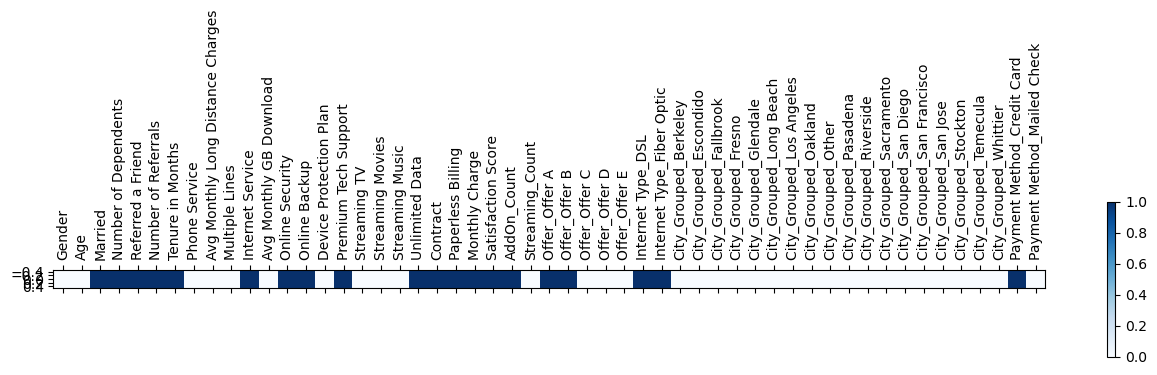

In [262]:
plt.matshow([top_fea],cmap="Blues", fignum =1)
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.colorbar()
plt.show()

In [263]:
Selected_best_columns = x_train_res.loc[:,best_pipe.named_steps['select'].get_support()].columns

In [264]:
## K Best Features with Score fuction F classif
print(*Selected_best_columns , sep ="\n")

Married
Number of Dependents
Referred a Friend
Number of Referrals
Tenure in Months
Internet Service
Online Security
Online Backup
Premium Tech Support
Unlimited Data
Contract
Paperless Billing
Monthly Charge
Satisfaction Score
AddOn_Count
Offer_Offer A
Offer_Offer B
Internet Type_DSL
Internet Type_Fiber Optic
Payment Method_Credit Card


## Feature selection using ANOVA F-test (SelectKBest with f_classif) identified key variables influencing churn behavior. 
## Customer engagement indicators such as referrals and add-on service usage showed strong predictive power, suggesting that higher ecosystem involvement reduces churn. Service adoption features like online security, backup, and premium support were also important, indicating that customers using more services are less likely to leave. 
## Additionally, tenure, satisfaction score, and contract type emerged as significant predictors, highlighting the importance of customer experience, service commitment, and relationship duration in churn prediction.

In [265]:
## Selected Features Filtering

x_train_sel_k = x_train_res.loc[:,top_fea]
x_test_sel_k = x_test.loc[:,top_fea]

## Implementing the Grid parameters in Logistic Model

In [266]:
grid_log = LogisticRegression(C=10, max_iter = 1000)

In [267]:
grid_log.fit(x_train_sel_k, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [268]:
grid_log.score(x_train_sel_k, y_train_res)

0.9626721430297174

In [269]:
grid_ypred = grid_log.predict(x_test_sel_k)

In [270]:
y_pred_proba_seg = grid_log.predict_proba(x_test_sel_k)

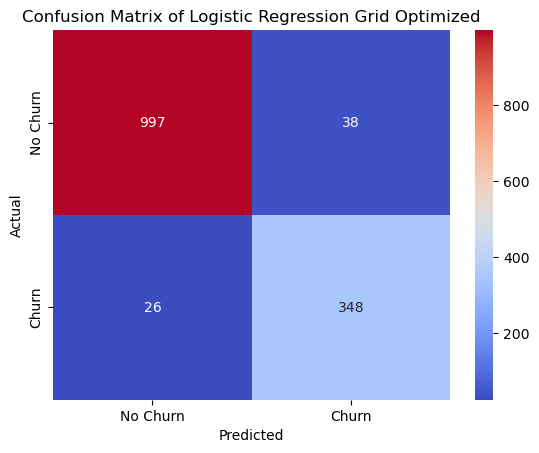

In [271]:
sb.heatmap( confusion_matrix(y_test,grid_ypred), 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Logistic Regression Grid Optimized")
plt.show()

In [272]:
grid_clrep = pd.DataFrame(classification_report(y_test,grid_ypred, output_dict = True))
grid_clrep

,0,1,accuracy,macro avg,weighted avg
precision,0.974585,0.901554,0.954578,0.938069,0.955200
recall,0.963285,0.930481,0.954578,0.946883,0.954578
f1-score,0.968902,0.915789,0.954578,0.942346,0.954804
support,1035.000000,374.000000,0.954578,1409.000000,1409.000000


## On Comparing both the tuned Logistic Regression and baseline model recall for churn class has improved in tuned model TP incresed, indicating slight better capability in identifying churn customers. However, the tuned model showed slight downgrade in precision, as predicting Real Non chuen customers to Churn 

In [273]:
grid_log.score(x_test_sel_k, y_test)

0.9545777146912704

In [274]:
grid_probs = grid_log.predict_proba(x_train_sel_k)

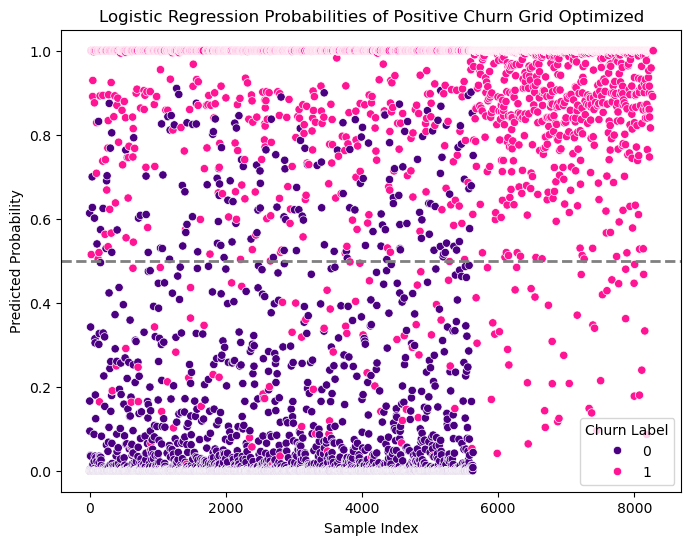

In [275]:
plt.figure(figsize=(8,6))

sb.scatterplot(
    x= range(len(grid_probs)),
    y= grid_probs[:,1],
    hue= y_train_res,
    palette=["#4B0082", "#FF1493"])
plt.axhline(y=0.5, color='grey', linestyle='--', linewidth=2)
plt.title("Logistic Regression Probabilities of Positive Churn Grid Optimized")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.show()

##  From Graph the predicted probability of churn is sparsed around 0.8 to 0.6 and Ourple non churn FP are visibly appears above 0.5 which decides the Recall value

# Evaluation of Logistic Regression with Selected Features 

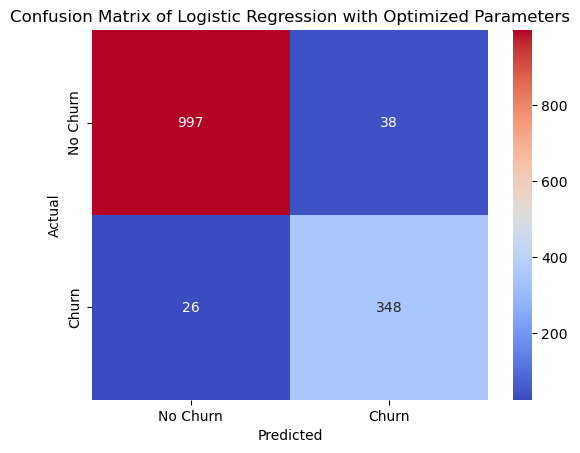

In [276]:
## Optimized Parameters Confusion Matrix 
sb.heatmap( confusion_matrix(y_test,grid_ypred), 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Logistic Regression with Optimized Parameters")
plt.show()

## The Selected models Prediction is accurate with even higher Weights 
## TN has predicted with 999 of 1035, TP churn prediction with 349 of 374
## FP with 36 and FN with 25 customers 

# Classification Report of Grid optimized Logistic Regression

In [277]:
pd.DataFrame(classification_report(y_test,grid_ypred, output_dict = True))

,0,1,accuracy,macro avg,weighted avg
precision,0.974585,0.901554,0.954578,0.938069,0.955200
recall,0.963285,0.930481,0.954578,0.946883,0.954578
f1-score,0.968902,0.915789,0.954578,0.942346,0.954804
support,1035.000000,374.000000,0.954578,1409.000000,1409.000000


## The selected features of 20 performs well with both Churn and Non churn 
## Precision recall anf f1 has performance bias slightly on Non churn prediction 

In [278]:
y_log_proba =  log_model.predict_proba(x_test)

In [279]:
## ROC curve
fpr, tpr, threshold = roc_curve(y_test,y_log_proba[:,0])

In [280]:
fpr_nc, tpr_nc, threshold_nc = roc_curve(y_test,y_log_proba[:,1])

In [281]:
auc_score = auc(fpr_nc, tpr_nc)

In [282]:
log_val.shape

(8278, 2)

# Receiver Operating Characteristic Curve Logistic Regression 

Text(0.5, 1.0, 'Receiver Operating Characteristic Curve')

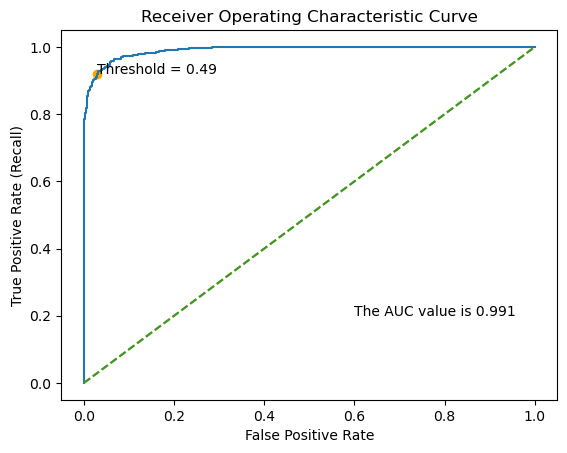

In [283]:

plt.figure()
idx = np.argmin(np.abs(threshold_nc - 0.5))

plt.plot(fpr_nc, tpr_nc)
plt.scatter(fpr_nc[idx], tpr_nc[idx], color ="orange")
plt.text(fpr_nc[idx],tpr_nc[idx], f"Threshold = {threshold_nc[idx]:.2f}")
plt.plot(([0,0],[1,1]),linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")

plt.text(0.6, 0.2, f"The AUC value is {auc_score:.3f}")
plt.title("Receiver Operating Characteristic Curve")


## It is the probability that a randomly chosen churn customer gets a higher score than a randomly chosen non-churn customer.
## The ROC curve is strongly skewed towards the top-left corner, indicating high True Positive Rate with very low False Positive Rate across multiple thresholds.
## Even at moderate thresholds (e.g., 0.5), the model maintains high recall while keeping FPR minimal, suggesting strong predictive stability.

# Buisness Insights
## The churn model demonstrates excellent discrimination ability (AUC = 0.992), meaning it can effectively rank customers based on churn risk.
## This allows the business to confidently target high-risk customers for retention campaigns while minimizing unnecessary intervention on low-risk customers.
## Because the False Positive Rate remains low, marketing resources can be allocated efficiently without over-targeting stable customers.

In [284]:
precision, recall, thresholds = precision_recall_curve(y_test,y_log_proba[:,1])

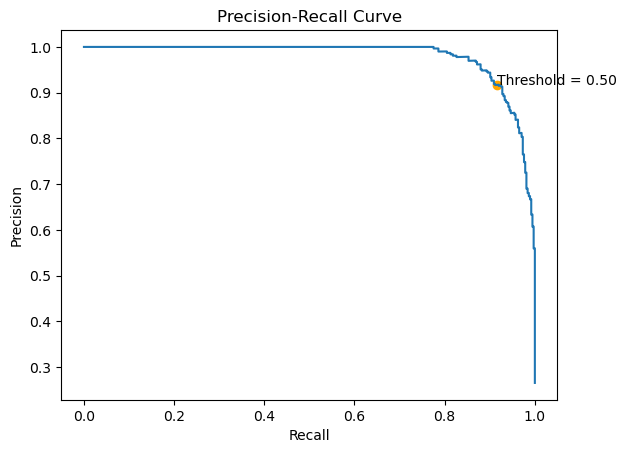

In [285]:
plt.figure()

idx = np.argmin(np.abs(thresholds - 0.5))

plt.plot(recall, precision)

plt.scatter(recall[idx], precision[idx], marker ="o", color ="orange")
plt.text(recall[idx], precision[idx],f"Threshold = {thresholds[idx]:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## The model can identify most churners before making many false alarms.
## You can target high-risk customers confidently.
## You can capture 80–90% of churners while still maintaining high campaign efficiency.
## That is very powerful in retention strategy.

In [286]:
from sklearn.calibration import calibration_curve

In [287]:
from sklearn.metrics import brier_score_loss
print(brier_score_loss(y_test,y_log_proba[:,1]))

0.03167286157742615


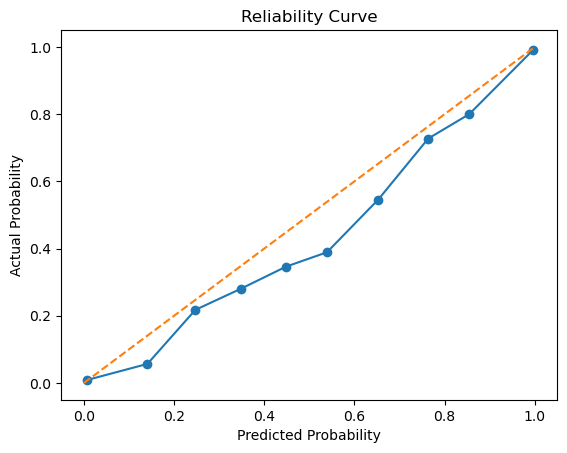

In [288]:
prob_true, prob_pred = calibration_curve(y_test, y_log_proba[:,1], n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Reliability Curve")
plt.show()

## Low probabilities (0.0–0.2)- Model slightly overestimating risk
## Mid range (0.3–0.6) Model underestimating risk
## High probabilities (0.8–1.0) Very close to diagonal wich is good
## Reasonably calibrated
## Slightly unstable in middle probability region
## Good at high-risk predictions